**Image Classification System Using Convolutional Neural Networks**

In [59]:
import numpy as np 
import matplotlib.pyplot as plt 
import tensorflow as tf 
from tensorflow.keras.datasets import cifar10

In [60]:
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPool2D,Dense,Flatten
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix


In [61]:
CLASS_NAMES = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

*loading the dataset*

In [62]:
(X_train_full,Y_train_full),(X_test,Y_test) = cifar10.load_data()

*Exploring the dataset*

In [63]:
print("Training images shape:",X_train_full.shape)
print("training labels shape:",Y_train_full.shape)
print("Test images shape:",X_test.shape)
print("test labels shape:",Y_test.shape)

Training images shape: (50000, 32, 32, 3)
training labels shape: (50000, 1)
Test images shape: (10000, 32, 32, 3)
test labels shape: (10000, 1)


In [64]:
print("pixel value range",X_train_full.min(),"to",X_train_full.max())

pixel value range 0 to 255


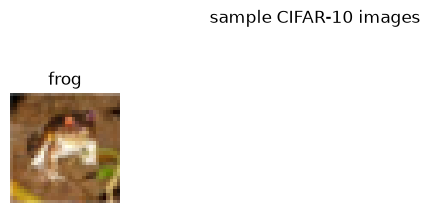

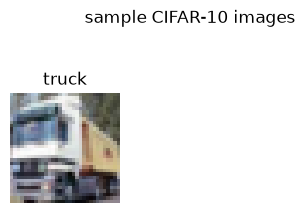

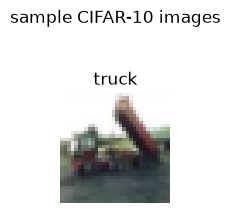

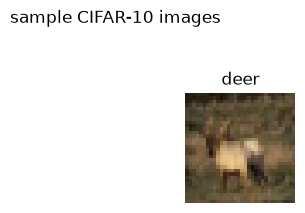

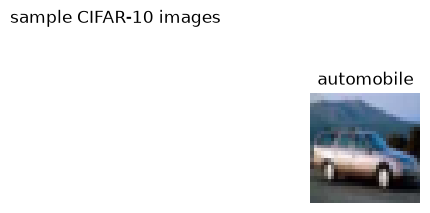

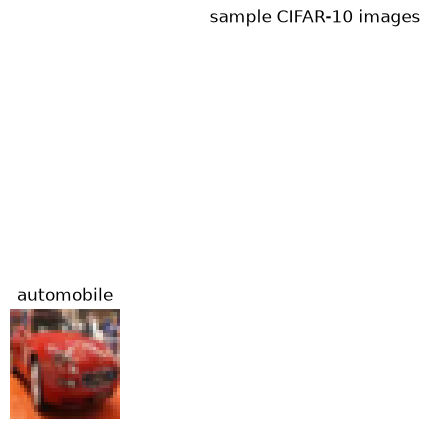

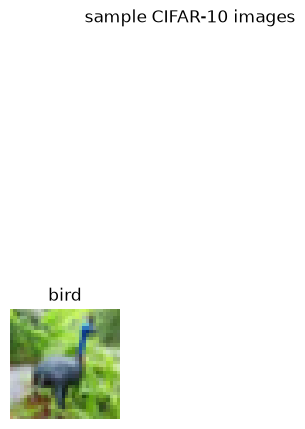

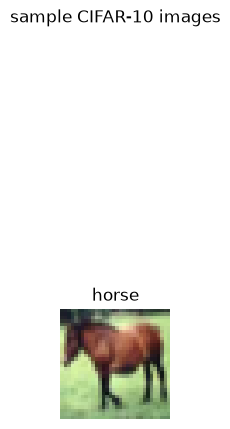

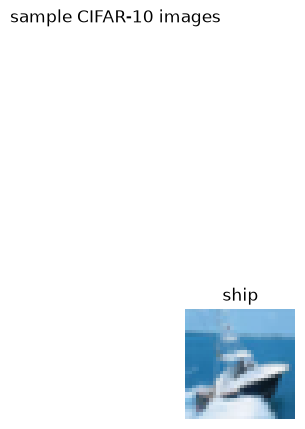

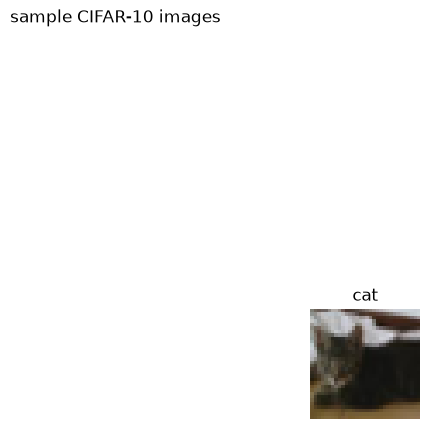

In [65]:
plt.Figure(figsize=(8,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train_full[i])
    plt.title(CLASS_NAMES[Y_train_full[i][0]])
    plt.axis('off')
    plt.suptitle("sample CIFAR-10 images")
    plt.tight_layout()
    plt.show()

In [66]:
print("single image shape:",X_train_full[0].shape)

single image shape: (32, 32, 3)


In [67]:
print("no of classes", len(CLASS_NAMES))

no of classes 10


*normalisation*

In [68]:
X_train_full = X_train_full.astype('float32')/255.0
X_test = X_test.astype('float32')/255.0

*train test valuation split*

In [69]:
x_train,x_val,y_train,y_val = train_test_split(X_train_full,Y_train_full,test_size=0.2,random_state=42)

In [70]:
y_train_cat = to_categorical(y_train, num_classes=10)
y_val_cat = to_categorical(y_val, num_classes=10)
y_test_cat = to_categorical(Y_test, num_classes=10)

**CNN MODEL**

In [71]:
model = Sequential([
Conv2D(32,(3,3),activation ='relu',padding='same',input_shape = (32,32,3)),
MaxPool2D((2,2)),
Conv2D(64,(3,3),activation ='relu',padding='same'),
MaxPool2D((2,2)),
Conv2D(64,(3,3),activation='relu',padding='same'),
Flatten(),Dense(64,activation='relu'),Dense(10,activation='softmax')
])

In [72]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 319,178 (1.22 MB)

 Trainable params: 319,178 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

*compiling the model*

In [73]:
model.compile(
    optimizer = Adam(),
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

*TRAINING*

In [74]:
EPOCHS = 15
BATCH_SIZE = 64

In [75]:
history = model.fit(
    x_train,y_train_cat,
    validation_data = (x_val,y_val_cat),
    epochs = EPOCHS,
    batch_size = BATCH_SIZE
)


Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.4233 - loss: 1.5833 - val_accuracy: 0.5449 - val_loss: 1.2941
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.5802 - loss: 1.1860 - val_accuracy: 0.6164 - val_loss: 1.0995
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.6463 - loss: 1.0035 - val_accuracy: 0.6337 - val_loss: 1.0319
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.6932 - loss: 0.8754 - val_accuracy: 0.6639 - val_loss: 0.9575
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.7230 - loss: 0.7890 - val_accuracy: 0.7032 - val_loss: 0.8660
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.7496 - loss: 0.7132 - val_accuracy: 0.7009 - val_loss: 0.8603
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.7722 - loss: 0.6526 - val_accuracy: 0.6924 - val_loss: 0.9054
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.7906 - loss: 0.5935 - 

*accuracy graph*

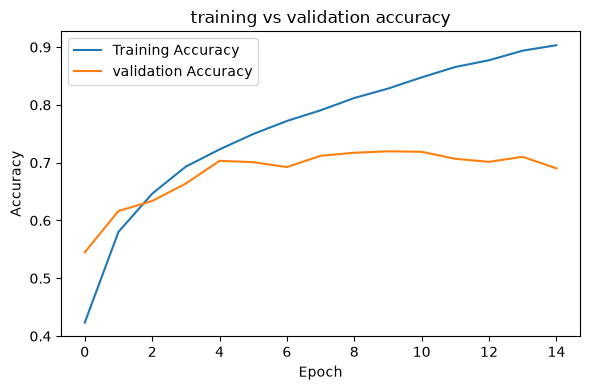

In [76]:
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label = 'Training Accuracy')
plt.plot(history.history['val_accuracy'],label ='validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('training vs validation accuracy')
plt.legend()
plt.tight_layout()
plt.show()

*loss graph*

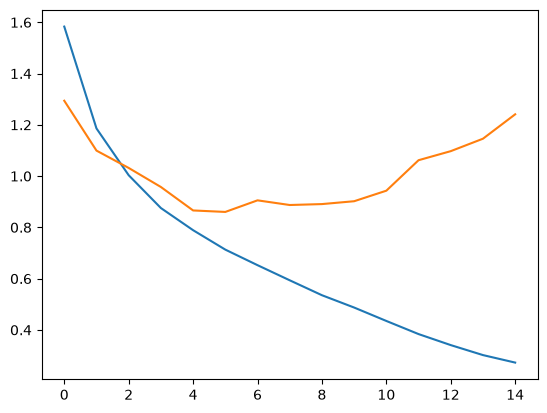

In [77]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

*testing*

In [78]:
test_loss,test_accuracy = model.evaluate(X_test,y_test_cat)
print(f"test loss:{test_loss:.4f}")
print(f"test accuracy:{test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6810 - loss: 1.2691
test loss:1.2691
test accuracy:0.6810


**generate predictions**

In [79]:
predictions = model.predict(X_test)
predicted_labels = np.argmax(predictions,axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [80]:
true_labels = Y_test.flatten()

**DISPLAY PREDICTIONS**

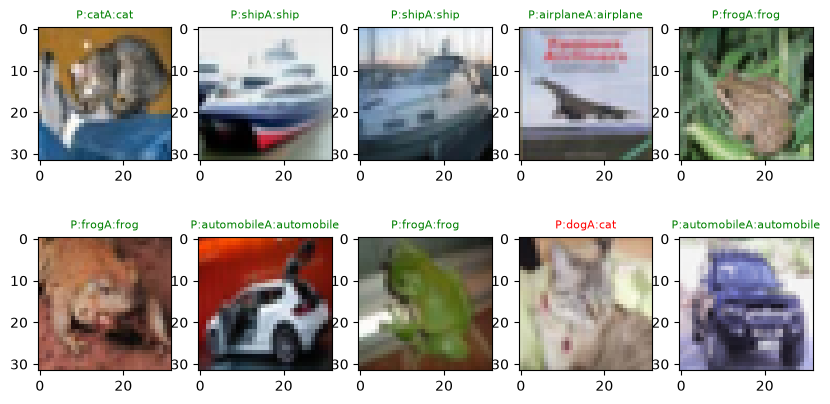

In [81]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i])
    color = 'green' if predicted_labels[i]==true_labels[i] else 'red'
    plt.title(
        f"P:{ CLASS_NAMES[predicted_labels[i]]}"
        f"A:{CLASS_NAMES[true_labels[i]]}",
        color = color ,fontsize = 8
    )

***CONFUSION MATRIX***

In [82]:
cm = confusion_matrix(true_labels,predicted_labels)

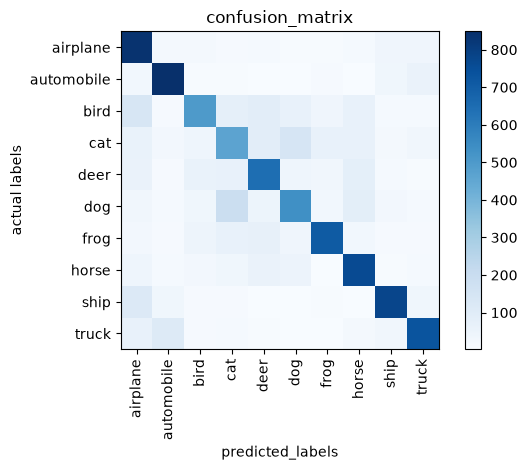

confusion matrix [[836  20  19   9  15   6   7  12  38  38]
 [ 28 849   6   7   4   2   9   5  32  58]
 [137  10 499  76  89  63  38  62  13  13]
 [ 61  22  40 464  90 143  65  64  20  31]
 [ 55  10  59  62 646  39  29  80  14   6]
 [ 30  12  35 193  46 536  28  86  22  12]
 [ 23   9  43  64  69  36 710  27  10   9]
 [ 41  12  23  35  56  49   4 761   6  13]
 [116  34  10  11   4   2   7   4 779  33]
 [ 65 114  11  12   7   5   5  21  30 730]]


In [83]:
plt.Figure(figsize=(8,6))
plt.imshow(cm,cmap = 'Blues')
plt.title('confusion_matrix')
plt.colorbar()
plt.xticks(range(10),CLASS_NAMES,rotation = 90)
plt.yticks(range(10),CLASS_NAMES)
plt.xlabel('predicted_labels')
plt.ylabel('actual labels')
plt.tight_layout()
plt.show()
print("confusion matrix",cm)

*conclusion*

In [84]:
print("---CONCLUSION---")
print(f"the CNN achieved a test accuracy of {test_accuracy:.2%} on CIFAR-10 DATASET")

---CONCLUSION---
the CNN achieved a test accuracy of 68.10% on CIFAR-10 DATASET


**TESTING WITH OTHER EXTERNAL PHOTOS**

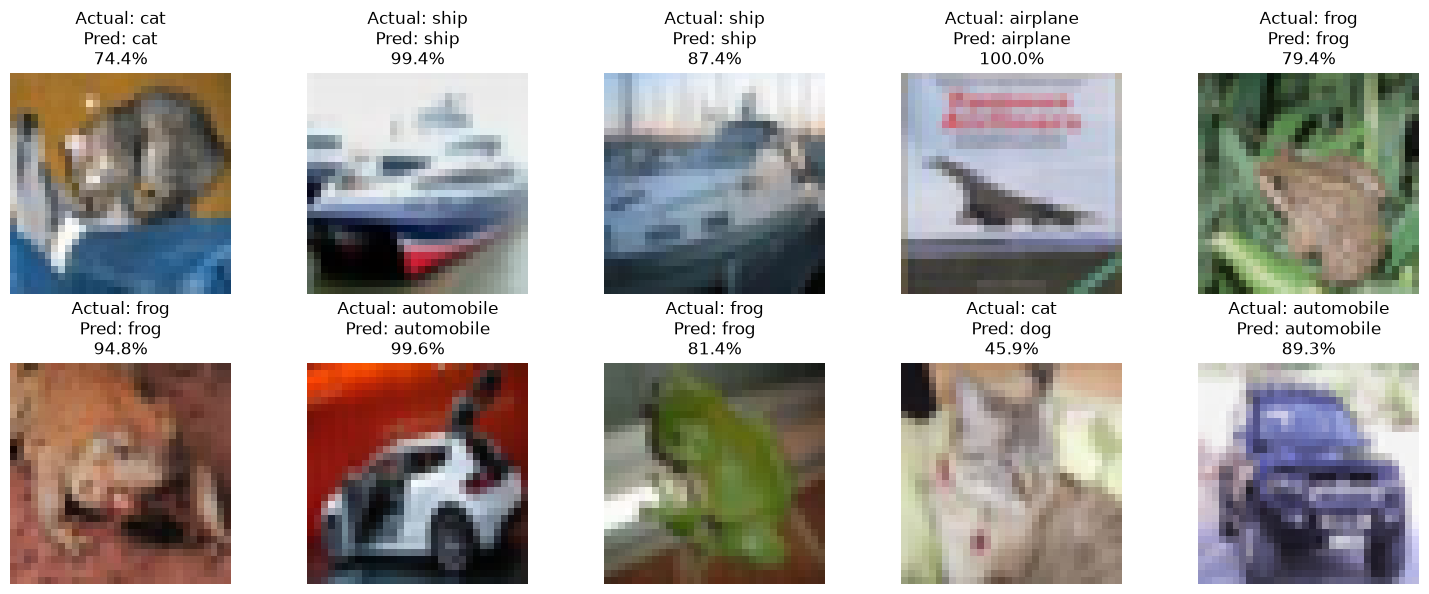

In [95]:
import numpy as np
import matplotlib.pyplot as plt

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

actual_classes = Y_test.flatten()

test_predictions = model.predict(X_test, verbose=0)
predicted_classes = np.argmax(test_predictions, axis=1)

plt.figure(figsize=(15, 6))

for i in range(10):
    confidence = test_predictions[i][predicted_classes[i]]

    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i])
    plt.axis("off")

    plt.title(
        f"Actual: {class_names[actual_classes[i]]}\n"
        f"Pred: {class_names[predicted_classes[i]]}\n"
        f"{confidence * 100:.1f}%"
    )

plt.tight_layout()
plt.show()

In [96]:
test_predictions = model.predict(X_test, verbose=0)

predicted_classes = np.argmax(test_predictions, axis=1)
actual_classes = Y_test.flatten()

accuracy = np.mean(predicted_classes == actual_classes)

print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 68.10%
